In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

SAVE_DIR = "/content/drive/MyDrive/HTR_Model"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory:", SAVE_DIR)
print("Directory created successfully!")

Save directory: /content/drive/MyDrive/HTR_Model
Directory created successfully!


In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.current_device())
else:
    print("No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
Number of GPUs: 1
Current GPU: 0


In [ ]:
!git clone -b member1-custom-cnn https://github.com/AdityaMishra26/HTR-CNN-Comparative-Analysis.git

Cloning into 'HTR-CNN-Comparative-Analysis'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 15 (delta 2), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 4.06 KiB | 4.06 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
%cd /content/HTR-CNN-Comparative-Analysis


/content/HTR-CNN-Comparative-Analysis


In [ ]:
!pwd
!git branch
!ls -R

/content/HTR-CNN-Comparative-Analysis
* member1-custom-cnn
.:
config.py  evaluate.py	notebooks  requirements.txt  train.py
data	   models	README.md  results	     utils

./data:
processed  raw

./data/processed:

./data/raw:

./models:
bilstm.py  custom_cnn.py  htr_model.py

./notebooks:

./results:

./utils:
dataset.py  decoder.py	metrics.py  preprocessing.py


In [ ]:
!pip install -q kaggle

In [7]:
import os
import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste your Kaggle API token: ")
print("Kaggle token loaded successfully!")

Paste your Kaggle API token: ··········
Kaggle token loaded successfully!


In [8]:
!mkdir -p data/raw
!kaggle datasets download -d nibinv23/iam-handwriting-word-database -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/nibinv23/iam-handwriting-word-database
License(s): unknown
100% 1.10G/1.10G [00:11<00:00, 107MB/s] 



In [11]:
!find data/raw -maxdepth 2 -type f | head -20

data/raw/words_new.txt
data/raw/iam_words/words.txt


In [12]:
!find data/raw/iam_words -type f | head -20

data/raw/iam_words/words.txt
data/raw/iam_words/words/g03/g03-040/g03-040-00-00.png
data/raw/iam_words/words/g03/g03-040/g03-040-00-06.png
data/raw/iam_words/words/g03/g03-040/g03-040-06-02.png
data/raw/iam_words/words/g03/g03-040/g03-040-02-03.png
data/raw/iam_words/words/g03/g03-040/g03-040-00-05.png
data/raw/iam_words/words/g03/g03-040/g03-040-01-04.png
data/raw/iam_words/words/g03/g03-040/g03-040-01-06.png
data/raw/iam_words/words/g03/g03-040/g03-040-02-07.png
data/raw/iam_words/words/g03/g03-040/g03-040-03-00.png
data/raw/iam_words/words/g03/g03-040/g03-040-05-06.png
data/raw/iam_words/words/g03/g03-040/g03-040-01-01.png
data/raw/iam_words/words/g03/g03-040/g03-040-03-04.png
data/raw/iam_words/words/g03/g03-040/g03-040-03-06.png
data/raw/iam_words/words/g03/g03-040/g03-040-05-02.png
data/raw/iam_words/words/g03/g03-040/g03-040-00-04.png
data/raw/iam_words/words/g03/g03-040/g03-040-04-00.png
data/raw/iam_words/words/g03/g03-040/g03-040-01-05.png
data/raw/iam_words/words/g03/g03-040

In [13]:
!find data/raw/iam_words/words -type f -name "*.png" | wc -l

115320


In [14]:
!head -20 data/raw/iam_words/words.txt


#--- words.txt ---------------------------------------------------------------#
#
# iam database word information
#
# format: a01-000u-00-00 ok 154 1 408 768 27 51 AT A
#
#     a01-000u-00-00  -> word id for line 00 in form a01-000u
#     ok              -> result of word segmentation
#                            ok: word was correctly
#                            er: segmentation of word can be bad
#
#     154             -> graylevel to binarize the line containing this word
#     1               -> number of components for this word
#     408 768 27 51   -> bounding box around this word in x,y,w,h format
#     AT              -> the grammatical tag for this word, see the
#                        file tagset.txt for an explanation
#     A               -> the transcription for this word
#
a01-000u-00-00 ok 154 408 768 27 51 AT A
a01-000u-00-01 ok 154 507 766 213 48 NN MOVE


In [15]:
from pathlib import Path

ANNOTATION_FILE = "data/raw/iam_words/words.txt"
IMAGES_ROOT = Path("data/raw/iam_words/words")

samples = []

with open(ANNOTATION_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # Skip comments and empty lines
        if not line or line.startswith("#"):
            continue

        parts = line.split()

        # We need at least ID, status, metadata and transcription
        if len(parts) < 9:
            continue

        word_id = parts[0]
        status = parts[1]

        # Skip badly segmented words
        if status != "ok":
            continue

        # Transcription starts after the first 8 columns
        transcription = " ".join(parts[8:])

        # Build IAM image path
        image_path = (
            IMAGES_ROOT
            / word_id.split("-")[0]
            / "-".join(word_id.split("-")[:2])
            / f"{word_id}.png"
        )

        # Keep only samples whose image actually exists
        if image_path.exists():
            samples.append({
                "image_path": str(image_path),
                "label": transcription
            })

print("Valid samples:", len(samples))

print("\nFirst 5 samples:")
for sample in samples[:5]:
    print(sample)

Valid samples: 38305

First 5 samples:
{'image_path': 'data/raw/iam_words/words/a01/a01-000u/a01-000u-00-00.png', 'label': 'A'}
{'image_path': 'data/raw/iam_words/words/a01/a01-000u/a01-000u-00-01.png', 'label': 'MOVE'}
{'image_path': 'data/raw/iam_words/words/a01/a01-000u/a01-000u-00-02.png', 'label': 'to'}
{'image_path': 'data/raw/iam_words/words/a01/a01-000u/a01-000u-00-03.png', 'label': 'stop'}
{'image_path': 'data/raw/iam_words/words/a01/a01-000u/a01-000u-00-04.png', 'label': 'Mr.'}


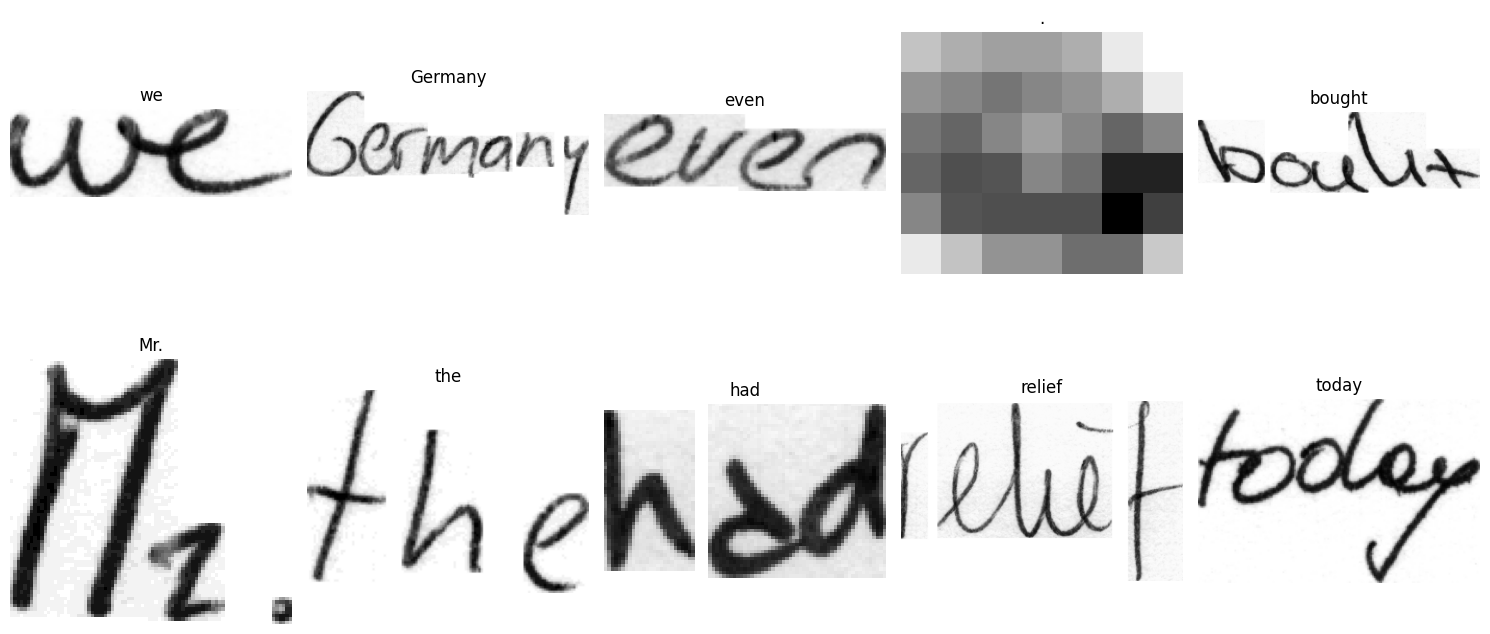

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Select 10 random samples
random_samples = random.sample(samples, 10)

plt.figure(figsize=(15, 8))

for i, sample in enumerate(random_samples):
    image = Image.open(sample["image_path"]).convert("L")

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(sample["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
bad_image_path = "data/raw/iam_words/words/a01/a01-117/a01-117-05-02.png"

samples = [
    sample for sample in samples
    if sample["image_path"] != bad_image_path
]

print("Samples after removing bad image:", len(samples))

Samples after removing bad image: 38304


In [18]:
bad_samples_remaining = [
    sample for sample in samples
    if sample["image_path"] == bad_image_path
]

print("Bad samples remaining:", len(bad_samples_remaining))

Bad samples remaining: 0


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def preprocess_image(image_path, img_height=64, max_width=256):
    """
    Preprocess IAM handwritten word images for CNN + BiLSTM.
    """

    # Load grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Get original dimensions
    h, w = image.shape

    # Resize while preserving aspect ratio
    new_width = int(w * (img_height / h))
    new_width = min(new_width, max_width)

    image = cv2.resize(
        image,
        (new_width, img_height),
        interpolation=cv2.INTER_CUBIC
    )

    # Create white canvas
    canvas = np.ones(
        (img_height, max_width),
        dtype=np.uint8
    ) * 255

    # Put resized word on the left
    canvas[:, :new_width] = image

    # Normalize pixels from [0, 255] → [0, 1]
    canvas = canvas.astype(np.float32) / 255.0

    return canvas

Original label: A
Processed shape: (64, 256)
Pixel range: 0.101960786 to 1.0


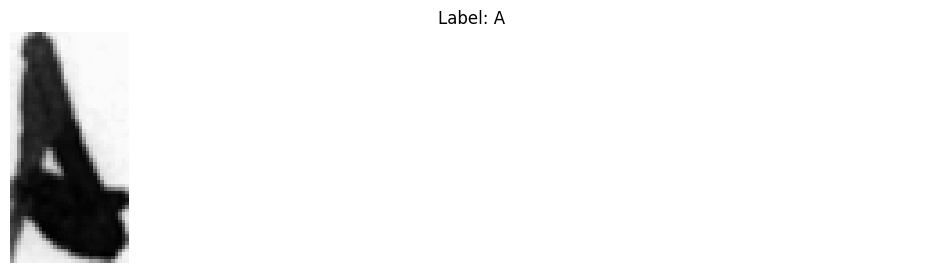

In [20]:
sample = samples[0]

processed_image = preprocess_image(sample["image_path"])

print("Original label:", sample["label"])
print("Processed shape:", processed_image.shape)
print("Pixel range:", processed_image.min(), "to", processed_image.max())

plt.figure(figsize=(14, 3))
plt.imshow(processed_image, cmap="gray")
plt.title(f"Label: {sample['label']}")
plt.axis("off")
plt.show()

In [21]:
# Collect all unique characters from labels
all_text = "".join(sample["label"] for sample in samples)

characters = sorted(list(set(all_text)))

print("Number of unique characters:", len(characters))
print("Characters:")
print(characters)

# Special tokens
PAD_TOKEN = "<PAD>"
BLANK_TOKEN = "<BLANK>"

# Character to index mapping
char_to_idx = {char: idx + 1 for idx, char in enumerate(characters)}

# Index to character mapping
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print("\nCharacter mapping example:")
print(list(char_to_idx.items())[:20])

Number of unique characters: 77
Characters:
[' ', '!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Character mapping example:
[(' ', 1), ('!', 2), ('"', 3), ('#', 4), ("'", 5), ('(', 6), (')', 7), ('*', 8), (',', 9), ('-', 10), ('.', 11), ('/', 12), ('0', 13), ('1', 14), ('2', 15), ('3', 16), ('4', 17), ('5', 18), ('6', 19), ('7', 20)]


In [22]:
def encode_label(text):
    """
    Convert a text label into a list of character indices.
    """
    return [char_to_idx[char] for char in text]


def decode_label(encoded):
    """
    Convert character indices back into text.
    """
    return "".join(idx_to_char[idx] for idx in encoded if idx != 0)


# Test encoding and decoding
test_text = samples[0]["label"]

encoded = encode_label(test_text)
decoded = decode_label(encoded)

print("Original text :", test_text)
print("Encoded       :", encoded)
print("Decoded       :", decoded)

Original text : A
Encoded       : [26]
Decoded       : A


In [23]:
from sklearn.model_selection import train_test_split

# Split dataset: 90% training, 10% validation
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("Total samples     :", len(samples))
print("Training samples  :", len(train_samples))
print("Validation samples:", len(val_samples))

Total samples     : 38304
Training samples  : 34473
Validation samples: 3831


In [24]:
import os

# Keep only samples whose image files actually exist
original_train_size = len(train_samples)
original_val_size = len(val_samples)

train_samples = [
    sample for sample in train_samples
    if os.path.exists(sample["image_path"])
]

val_samples = [
    sample for sample in val_samples
    if os.path.exists(sample["image_path"])
]

print("Missing images removed from training:",
      original_train_size - len(train_samples))

print("Missing images removed from validation:",
      original_val_size - len(val_samples))

print("\nFinal training samples:", len(train_samples))
print("Final validation samples:", len(val_samples))

Missing images removed from training: 0
Missing images removed from validation: 0

Final training samples: 34473
Final validation samples: 3831


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np


class IAMWordDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load and preprocess image
        image = preprocess_image(sample["image_path"])

        # Convert NumPy image to PyTorch tensor
        # Shape: (64, 256) -> (1, 64, 256)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

        # Encode text label
        label = torch.tensor(
            encode_label(sample["label"]),
            dtype=torch.long
        )

        return {
            "image": image,
            "label": label,
            "text": sample["label"]
        }


# Create datasets
train_dataset = IAMWordDataset(train_samples)
val_dataset = IAMWordDataset(val_samples)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

# Test one sample
sample = train_dataset[0]

print("\nImage shape:", sample["image"].shape)
print("Text label:", sample["text"])
print("Encoded label:", sample["label"])

Train dataset size: 34473
Validation dataset size: 3831

Image shape: torch.Size([1, 64, 256])
Text label: allow
Encoded label: tensor([52, 63, 63, 66, 74])


In [26]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    # Stack images
    images = torch.stack([item["image"] for item in batch])

    # Get variable-length labels
    labels = [item["label"] for item in batch]

    # Length of each label before padding
    label_lengths = torch.tensor(
        [len(label) for label in labels],
        dtype=torch.long
    )

    # Pad labels with 0
    # 0 is reserved for the CTC blank token
    labels_padded = pad_sequence(
        labels,
        batch_first=True,
        padding_value=0
    )

    # Original text labels
    texts = [item["text"] for item in batch]

    return {
        "images": images,
        "labels": labels_padded,
        "label_lengths": label_lengths,
        "texts": texts
    }


BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 539
Validation batches: 60


In [29]:
batch = next(iter(train_loader))

print("Images shape:", batch["images"].shape)
print("Labels shape:", batch["labels"].shape)
print("Label lengths:", batch["label_lengths"][:10])
print("First 5 texts:", batch["texts"][:5])

Images shape: torch.Size([64, 1, 64, 256])
Labels shape: torch.Size([64, 12])
Label lengths: tensor([1, 2, 2, 4, 3, 5, 6, 3, 6, 6])
First 5 texts: ['.', 'of', 'is', 'Only', 'the']


In [30]:
import torch
import torch.nn as nn


class CustomCNNHTR(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNNHTR, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # Input: (B, 1, 64, 256)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (B, 64, 32, 128)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (B, 128, 16, 64)

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),  # (B, 256, 8, 64)

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),  # (B, 256, 4, 64)
        )

        # Convert CNN features into a sequence
        self.feature_projection = nn.Linear(256 * 4, 256)

        # Sequence model
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        # Character classifier
        # +1 because class 0 is reserved for CTC blank
        self.classifier = nn.Linear(512, num_classes + 1)

    def forward(self, x):
        x = self.cnn(x)

        # x shape: (B, 256, 4, 64)
        batch_size, channels, height, width = x.size()

        # Convert width dimension into time steps
        x = x.permute(0, 3, 1, 2)       # (B, 64, 256, 4)
        x = x.contiguous().view(batch_size, width, channels * height)

        # Project features
        x = self.feature_projection(x)  # (B, 64, 256)

        # BiLSTM
        x, _ = self.lstm(x)             # (B, 64, 512)

        # Character predictions
        x = self.classifier(x)          # (B, 64, 78)

        return x


# 77 characters + CTC blank handled inside the model
model = CustomCNNHTR(num_classes=len(characters))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Number of characters:", len(characters))
print("Output classes:", len(characters) + 1)

# Test with one batch
test_images = batch["images"].to(device)

with torch.no_grad():
    output = model(test_images)

print("Input shape :", test_images.shape)
print("Output shape:", output.shape)

Device: cuda
Number of characters: 77
Output classes: 78
Input shape : torch.Size([64, 1, 64, 256])
Output shape: torch.Size([64, 64, 78])


In [31]:
# Create a completely fresh model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNNHTR(num_classes=len(characters))
model = model.to(device)

print("Fresh model created successfully!")
print("Device:", device)
print("Number of characters:", len(characters))
print("Output classes:", len(characters) + 1)

Fresh model created successfully!
Device: cuda
Number of characters: 77
Output classes: 78


In [32]:
import torch.nn as nn

# -------------------------
# CTC Loss
# -------------------------
criterion = nn.CTCLoss(
    blank=0,
    reduction="mean",
    zero_infinity=True
)

# -------------------------
# Optimizer
# -------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# -------------------------
# Learning Rate Scheduler
# -------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("CTC Loss configured successfully!")
print("Optimizer:", optimizer)
print("Initial Learning Rate:", optimizer.param_groups[0]["lr"])
print("Scheduler configured successfully!")

CTC Loss configured successfully!
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)
Initial Learning Rate: 0.0005
Scheduler configured successfully!


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(optimizer.param_groups[0]["lr"])

0.0005


In [ ]:
import torch.nn.functional as F

# CTC Loss
# blank=0 because index 0 is reserved for the CTC blank token
criterion = nn.CTCLoss(
    blank=0,
    reduction="mean",
    zero_infinity=True
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("CTC Loss configured successfully!")
print("Optimizer:", optimizer)

CTC Loss configured successfully!
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
import torch
import torch.nn.functional as F

batch = next(iter(train_loader))

images = batch["images"].to(device)
labels = batch["labels"].to(device)
label_lengths = batch["label_lengths"].to(device)

print("Labels shape:", labels.shape)
print("Label lengths:", label_lengths[:10])
print("Min label value:", labels.min().item())
print("Max label value:", labels.max().item())

model.eval()

with torch.no_grad():
    outputs = model(images)

print("\nModel output shape:", outputs.shape)

log_probs = F.log_softmax(outputs, dim=2).permute(1, 0, 2)

input_lengths = torch.full(
    (images.size(0),),
    outputs.size(1),
    dtype=torch.long,
    device=device
)

loss = criterion(
    log_probs,
    labels,
    input_lengths,
    label_lengths
)

print("\nCTC Loss for one batch:", loss.item())
print("NaN in loss:", torch.isnan(loss).item())

Labels shape: torch.Size([64, 13])
Label lengths: tensor([2, 8, 8, 2, 1, 4, 5, 3, 1, 2], device='cuda:0')
Min label value: 0
Max label value: 76

Model output shape: torch.Size([64, 64, 78])

CTC Loss for one batch: 104.7120361328125
NaN in loss: False


In [34]:
# Reset training tracking variables
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs_without_improvement = 0

print("Training tracking variables reset successfully!")

Training tracking variables reset successfully!


In [ ]:
print("Number of characters:", len(characters))

print("\nFirst 10 characters:")
print(characters[:10])

print("\nFirst 10 character mappings:")
for ch in characters[:10]:
    print(repr(ch), "->", char_to_idx[ch])

print("\nMinimum index:", min(char_to_idx.values()))
print("Maximum index:", max(char_to_idx.values()))

print("\nDoes index 0 belong to a character?",
      0 in char_to_idx.values())

Number of characters: 77

First 10 characters:
[' ', '!', '"', '#', "'", '(', ')', '*', ',', '-']

First 10 character mappings:
' ' -> 1
'!' -> 2
'"' -> 3
'#' -> 4
"'" -> 5
'(' -> 6
')' -> 7
'*' -> 8
',' -> 9
'-' -> 10

Minimum index: 1
Maximum index: 77

Does index 0 belong to a character? False


In [35]:
import torch
from tqdm.auto import tqdm

NUM_EPOCHS = 50

# Tracking
train_losses = []
val_losses = []

best_val_loss = float("inf")

# Early stopping
patience = 7
epochs_without_improvement = 0


for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"
    )

    for batch in progress_bar:

        images = batch["images"].to(device)
        labels = batch["labels"].to(device)
        label_lengths = batch["label_lengths"].to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # (B, T, C) -> (T, B, C)
        log_probs = outputs.log_softmax(2).permute(1, 0, 2)

        batch_size = images.size(0)
        time_steps = outputs.size(1)

        input_lengths = torch.full(
            (batch_size,),
            time_steps,
            dtype=torch.long,
            device=device
        )

        # CTC Loss
        # Flatten only the valid characters
        targets = torch.cat([
            labels[i, :label_lengths[i]]
            for i in range(labels.size(0))
        ])

        loss = criterion(
            log_probs,
            targets,
            input_lengths,
            label_lengths
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # ==========================================
    # VALIDATION
    # ==========================================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for batch in tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"
        ):

            images = batch["images"].to(device)
            labels = batch["labels"].to(device)
            label_lengths = batch["label_lengths"].to(device)

            outputs = model(images)

            log_probs = outputs.log_softmax(2).permute(1, 0, 2)

            batch_size = images.size(0)
            time_steps = outputs.size(1)

            input_lengths = torch.full(
                (batch_size,),
                time_steps,
                dtype=torch.long,
                device=device
            )

            targets = torch.cat([
                labels[i, :label_lengths[i]]
                for i in range(labels.size(0))
            ])

            loss = criterion(
                log_probs,
                targets,
                input_lengths,
                label_lengths
            )

            running_val_loss += loss.item()


    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # Update learning rate based on validation loss
    scheduler.step(epoch_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
    )


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": epoch_val_loss,
        }, "/content/drive/MyDrive/HTR_Model/best_custom_cnn_htr.pth")

        print("✓ New best model saved!")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement for "
            f"{epochs_without_improvement}/{patience} epochs"
        )


    # ==========================================
    # EARLY STOPPING
    # ==========================================
    if epochs_without_improvement >= patience:

        print("\nEarly stopping triggered!")
        break
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
}, "/content/drive/MyDrive/HTR_Model/final_training_backup.pth")

print("Final training backup saved to Google Drive!")

Epoch 1/50 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


Epoch [1/50] | Train Loss: 3.6165 | Val Loss: 2.2953 | LR: 5.00e-04
✓ New best model saved!


Epoch 2/50 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]

...

Epoch 26/50 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


Epoch [26/50] | Train Loss: 0.0134 | Val Loss: 0.3459 | LR: 6.25e-05
No improvement for 6/7 epochs


Epoch 27/50 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 27/50 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


Epoch [27/50] | Train Loss: 0.0101 | Val Loss: 0.3436 | LR: 6.25e-05
No improvement for 7/7 epochs

Early stopping triggered!
Final training backup saved to Google Drive!


In [36]:
import os
import torch

MODEL_PATH = "/content/drive/MyDrive/HTR_Model/best_custom_cnn_htr.pth"

print("Best model exists:", os.path.exists(MODEL_PATH))

if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)

    print("\nBest Model Information:")
    print("Best Epoch:", checkpoint["epoch"])
    print("Best Validation Loss:", checkpoint["val_loss"])

Best model exists: True

Best Model Information:
Best Epoch: 20
Best Validation Loss: 0.30927801728248594


In [37]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"✓ Best model loaded successfully!")
print(f"Best Epoch: {checkpoint['epoch']}")
print(f"Best Validation Loss: {checkpoint['val_loss']:.4f}")

✓ Best model loaded successfully!
Best Epoch: 20
Best Validation Loss: 0.3093


In [38]:
import torch

# Reverse mapping: index -> character
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

def ctc_greedy_decode(outputs):
    """
    Greedy CTC decoding.
    outputs shape: (B, T, C)
    """
    predicted_indices = outputs.argmax(dim=2)

    decoded_texts = []

    for sequence in predicted_indices:
        text = []
        previous = -1

        for idx in sequence.cpu().tolist():

            # Remove CTC blank (0) and repeated characters
            if idx != 0 and idx != previous:
                text.append(idx_to_char.get(idx, ""))

            previous = idx

        decoded_texts.append("".join(text))

    return decoded_texts


# Get one validation batch
batch = next(iter(val_loader))

images = batch["images"].to(device)
true_texts = batch["texts"]

# Predict
model.eval()

with torch.no_grad():
    outputs = model(images)

predicted_texts = ctc_greedy_decode(outputs)

# Display first 10 predictions
for i in range(10):
    print(f"{i+1}. True:      {true_texts[i]}")
    print(f"   Predicted: {predicted_texts[i]}")
    print("-" * 50)

1. True:      Fang-
   Predicted: Fang-
--------------------------------------------------
2. True:      ,
   Predicted: ,
--------------------------------------------------
3. True:      -
   Predicted: -
--------------------------------------------------
4. True:      course
   Predicted: Cawege
--------------------------------------------------
5. True:      in
   Predicted: in
--------------------------------------------------
6. True:      are
   Predicted: are
--------------------------------------------------
7. True:      parties
   Predicted: pastiers
--------------------------------------------------
8. True:      dealing
   Predicted: dealing
--------------------------------------------------
9. True:      troops
   Predicted: troops
--------------------------------------------------
10. True:      "
   Predicted: "
--------------------------------------------------


In [39]:
import torch
from tqdm.auto import tqdm

# =========================================================
# EDIT DISTANCE FUNCTION
# =========================================================
def levenshtein_distance(ref, hyp):
    """
    Calculate edit distance between reference and prediction.
    """
    m = len(ref)
    n = len(hyp)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )

    return dp[m][n]


# =========================================================
# GREEDY CTC DECODER
# =========================================================
def ctc_greedy_decode(outputs):
    """
    Decode model output using greedy CTC decoding.
    Removes:
    1. Repeated consecutive predictions
    2. Blank token (0)
    """

    predicted_indices = torch.argmax(outputs, dim=2)

    decoded_texts = []

    for sequence in predicted_indices:

        previous_token = None
        decoded = []

        for token in sequence.tolist():

            # Skip repeated consecutive tokens
            if token == previous_token:
                continue

            # Ignore CTC blank token
            if token != 0:
                decoded.append(token)

            previous_token = token

        # Convert token IDs to characters
        text = "".join(
            idx_to_char[idx]
            for idx in decoded
            if idx in idx_to_char
        )

        decoded_texts.append(text)

    return decoded_texts


# =========================================================
# COMPLETE VALIDATION EVALUATION
# =========================================================
model.eval()

total_samples = 0
exact_matches = 0

total_char_errors = 0
total_reference_characters = 0

total_word_errors = 0
total_reference_words = 0

all_predictions = []
all_ground_truths = []

with torch.no_grad():

    for batch in tqdm(val_loader, desc="Evaluating validation set"):

        images = batch["images"].to(device)

        # Ground truth text
        true_texts = batch["texts"]

        # Model prediction
        outputs = model(images)

        # Decode predictions
        predicted_texts = ctc_greedy_decode(outputs)

        # Evaluate every sample
        for true_text, predicted_text in zip(
            true_texts,
            predicted_texts
        ):

            # Store results
            all_ground_truths.append(true_text)
            all_predictions.append(predicted_text)

            total_samples += 1

            # -------------------------------------------------
            # EXACT MATCH
            # -------------------------------------------------
            if true_text == predicted_text:
                exact_matches += 1

            # -------------------------------------------------
            # CHARACTER ERROR RATE
            # -------------------------------------------------
            char_errors = levenshtein_distance(
                true_text,
                predicted_text
            )

            total_char_errors += char_errors
            total_reference_characters += len(true_text)

            # -------------------------------------------------
            # WORD ERROR RATE
            # -------------------------------------------------
            true_words = true_text.split()
            predicted_words = predicted_text.split()

            word_errors = levenshtein_distance(
                true_words,
                predicted_words
            )

            total_word_errors += word_errors
            total_reference_words += len(true_words)


# =========================================================
# FINAL METRICS
# =========================================================

CER = (
    total_char_errors / total_reference_characters
    if total_reference_characters > 0 else 0
)

WER = (
    total_word_errors / total_reference_words
    if total_reference_words > 0 else 0
)

exact_match_accuracy = (
    exact_matches / total_samples * 100
    if total_samples > 0 else 0
)


# =========================================================
# PRINT RESULTS
# =========================================================
print("\n" + "=" * 60)
print("       COMPLETE HTR MODEL EVALUATION RESULTS")
print("=" * 60)

print(f"Total Validation Samples     : {total_samples}")
print(f"Exact Correct Predictions    : {exact_matches}")

print("-" * 60)

print(f"Exact Match Accuracy         : {exact_match_accuracy:.2f}%")
print(f"Character Error Rate (CER)   : {CER:.4f} ({CER * 100:.2f}%)")
print(f"Word Error Rate (WER)        : {WER:.4f} ({WER * 100:.2f}%)")

print("-" * 60)

print(f"Character Accuracy (1-CER)   : {(1 - CER) * 100:.2f}%")
print(f"Word Accuracy (1-WER)        : {(1 - WER) * 100:.2f}%")

print("=" * 60)

Evaluating validation set:   0%|          | 0/60 [00:00<?, ?it/s]


       COMPLETE HTR MODEL EVALUATION RESULTS
Total Validation Samples     : 3831
Exact Correct Predictions    : 2949
------------------------------------------------------------
Exact Match Accuracy         : 76.98%
Character Error Rate (CER)   : 0.0859 (8.59%)
Word Error Rate (WER)        : 0.2306 (23.06%)
------------------------------------------------------------
Character Accuracy (1-CER)   : 91.41%
Word Accuracy (1-WER)        : 76.94%


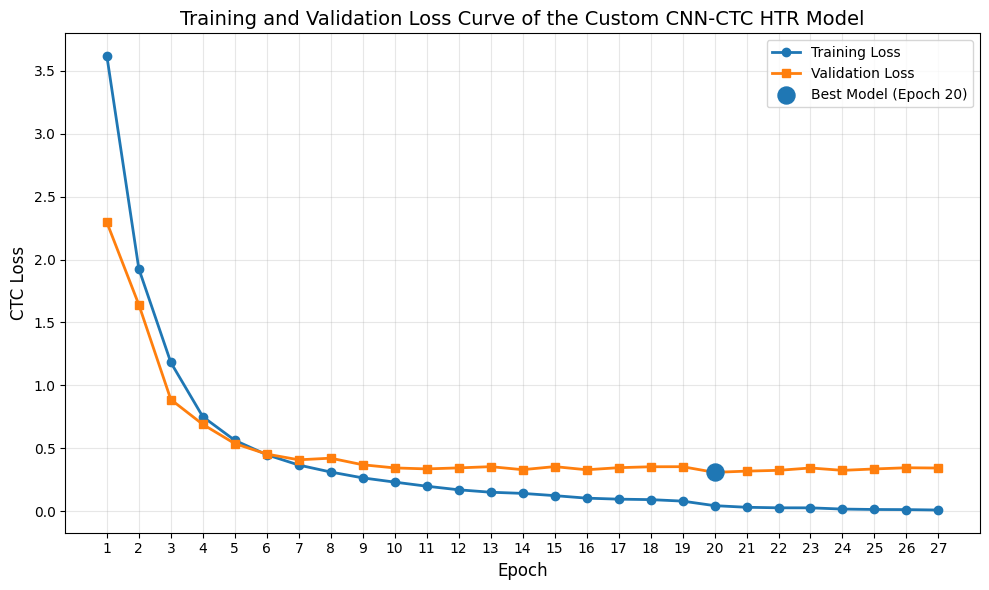

✓ Graph saved successfully to:
/content/drive/MyDrive/HTR_Model/training_validation_loss_curve.png


In [40]:
import matplotlib.pyplot as plt

# Number of completed epochs
epochs = range(1, len(train_losses) + 1)

# Create figure
plt.figure(figsize=(10, 6))

# Training loss
plt.plot(
    epochs,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

# Validation loss
plt.plot(
    epochs,
    val_losses,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

# Mark best validation epoch
best_epoch = 20
best_loss = min(val_losses)

plt.scatter(
    best_epoch,
    best_loss,
    s=150,
    zorder=5,
    label=f"Best Model (Epoch {best_epoch})"
)

# Labels
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("CTC Loss", fontsize=12)
plt.title("Training and Validation Loss Curve of the Custom CNN-CTC HTR Model",
          fontsize=14)

plt.xticks(range(1, len(train_losses) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save high-quality image for research paper
save_path = "/content/drive/MyDrive/HTR_Model/training_validation_loss_curve.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Graph saved successfully to:\n{save_path}")

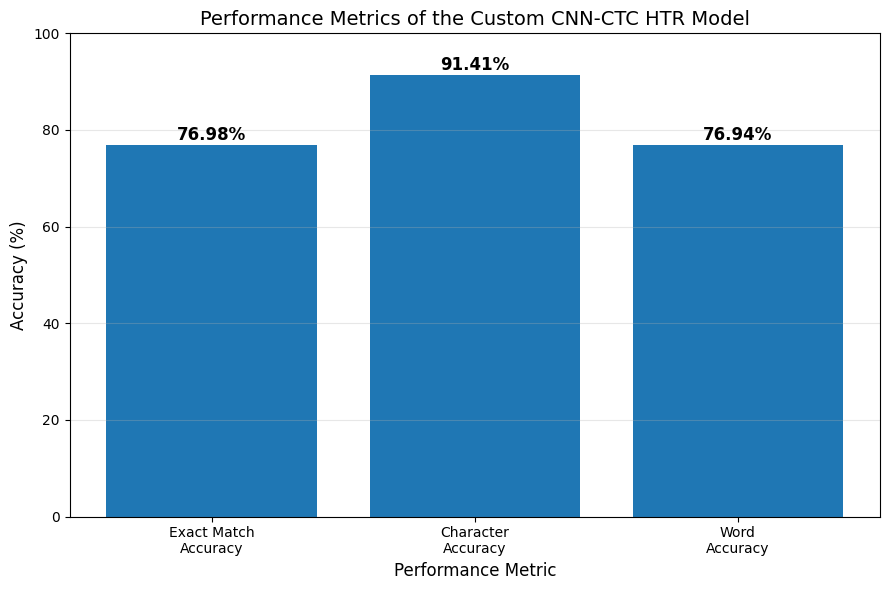

✓ Figure saved successfully to:
/content/drive/MyDrive/HTR_Model/performance_metrics_bar_chart.png


In [41]:
import matplotlib.pyplot as plt

# Actual evaluation results
metrics = [
    "Exact Match\nAccuracy",
    "Character\nAccuracy",
    "Word\nAccuracy"
]

values = [
    76.98,
    91.41,
    76.94
]

# Create figure
plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, values)

# Add values on top of bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.xlabel("Performance Metric", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title(
    "Performance Metrics of the Custom CNN-CTC HTR Model",
    fontsize=14
)

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save for research paper
save_path = "/content/drive/MyDrive/HTR_Model/performance_metrics_bar_chart.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Figure saved successfully to:\n{save_path}")

In [55]:
# ============================================================
# COMPLETE HTR EVALUATION
# Exact Match + CER + WER + Precision + Recall + F1
# ============================================================

import torch
from tqdm.auto import tqdm
from collections import Counter

model.eval()

all_true_texts = []
all_pred_texts = []

with torch.no_grad():

    for batch in tqdm(val_loader, desc="Evaluating validation set"):

        images = batch["images"].to(device)

        # Model prediction
        outputs = model(images)

        # Get predicted class indices
        predicted_indices = outputs.argmax(dim=2)

        # Decode every sample in the batch
        for i in range(images.size(0)):

            # ------------------------------------------------
            # GROUND TRUTH
            # ------------------------------------------------
            true_length = batch["label_lengths"][i].item()

            true_indices = (
                batch["labels"][i][:true_length]
                .cpu()
                .tolist()
            )

            # Decode ground truth
            true_text = "".join(
                characters[idx - 1]
                for idx in true_indices
                if idx > 0
            )

            # ------------------------------------------------
            # PREDICTION WITH CTC DECODING
            # ------------------------------------------------
            pred_indices = (
                predicted_indices[i]
                .cpu()
                .tolist()
            )

            decoded = []
            previous = -1

            for idx in pred_indices:

                # CTC blank = 0
                if idx != 0 and idx != previous:
                    decoded.append(characters[idx - 1])

                previous = idx

            pred_text = "".join(decoded)

            # Save results
            all_true_texts.append(true_text)
            all_pred_texts.append(pred_text)


# ============================================================
# 1. EXACT MATCH ACCURACY
# ============================================================

correct_predictions = sum(
    true == pred
    for true, pred in zip(all_true_texts, all_pred_texts)
)

total_samples = len(all_true_texts)

exact_match_accuracy = (
    correct_predictions / total_samples * 100
)


# ============================================================
# 2. CER / WER
# ============================================================

def levenshtein_distance(reference, hypothesis):

    rows = len(reference) + 1
    cols = len(hypothesis) + 1

    dp = [[0] * cols for _ in range(rows)]

    for i in range(rows):
        dp[i][0] = i

    for j in range(cols):
        dp[0][j] = j

    for i in range(1, rows):
        for j in range(1, cols):

            if reference[i - 1] == hypothesis[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,       # Deletion
                dp[i][j - 1] + 1,       # Insertion
                dp[i - 1][j - 1] + cost # Substitution
            )

    return dp[-1][-1]


total_char_errors = 0
total_chars = 0

total_word_errors = 0
total_words = 0

for true_text, pred_text in zip(all_true_texts, all_pred_texts):

    # CER
    total_char_errors += levenshtein_distance(
        true_text,
        pred_text
    )

    total_chars += len(true_text)

    # WER
    true_words = true_text.split()
    pred_words = pred_text.split()

    total_word_errors += levenshtein_distance(
        true_words,
        pred_words
    )

    total_words += len(true_words)


cer = total_char_errors / total_chars
wer = total_word_errors / total_words


# ============================================================
# 3. CHARACTER-LEVEL PRECISION / RECALL / F1
# ============================================================

total_tp = 0
total_fp = 0
total_fn = 0

for true_text, pred_text in zip(all_true_texts, all_pred_texts):

    true_counter = Counter(true_text)
    pred_counter = Counter(pred_text)

    # Matching characters
    tp = sum(
        min(true_counter[char], pred_counter[char])
        for char in true_counter
    )

    # Extra predicted characters
    fp = len(pred_text) - tp

    # Missing ground-truth characters
    fn = len(true_text) - tp

    total_tp += tp
    total_fp += fp
    total_fn += fn


precision = (
    total_tp / (total_tp + total_fp)
    if (total_tp + total_fp) > 0
    else 0
)

recall = (
    total_tp / (total_tp + total_fn)
    if (total_tp + total_fn) > 0
    else 0
)

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)


# ============================================================
# 4. FINAL RESULTS
# ============================================================

print("=" * 65)
print("       COMPLETE HTR MODEL EVALUATION RESULTS")
print("=" * 65)

print(f"Total Validation Samples     : {total_samples}")
print(f"Exact Correct Predictions    : {correct_predictions}")

print("-" * 65)

print(f"Exact Match Accuracy         : {exact_match_accuracy:.2f}%")
print(f"Character Error Rate (CER)   : {cer:.4f} ({cer*100:.2f}%)")
print(f"Word Error Rate (WER)        : {wer:.4f} ({wer*100:.2f}%)")

print("-" * 65)

print(f"Character Accuracy (1-CER)   : {(1-cer)*100:.2f}%")
print(f"Word Accuracy (1-WER)        : {(1-wer)*100:.2f}%")

print("-" * 65)

print("CHARACTER-LEVEL CLASSIFICATION METRICS")
print(f"Precision                    : {precision*100:.2f}%")
print(f"Recall                       : {recall*100:.2f}%")
print(f"F1-Score                     : {f1_score*100:.2f}%")

print("=" * 65)

Evaluating validation set:   0%|          | 0/60 [00:00<?, ?it/s]

       COMPLETE HTR MODEL EVALUATION RESULTS
Total Validation Samples     : 3831
Exact Correct Predictions    : 2949
-----------------------------------------------------------------
Exact Match Accuracy         : 76.98%
Character Error Rate (CER)   : 0.0859 (8.59%)
Word Error Rate (WER)        : 0.2306 (23.06%)
-----------------------------------------------------------------
Character Accuracy (1-CER)   : 91.41%
Word Accuracy (1-WER)        : 76.94%
-----------------------------------------------------------------
CHARACTER-LEVEL CLASSIFICATION METRICS
Precision                    : 93.31%
Recall                       : 92.57%
F1-Score                     : 92.94%


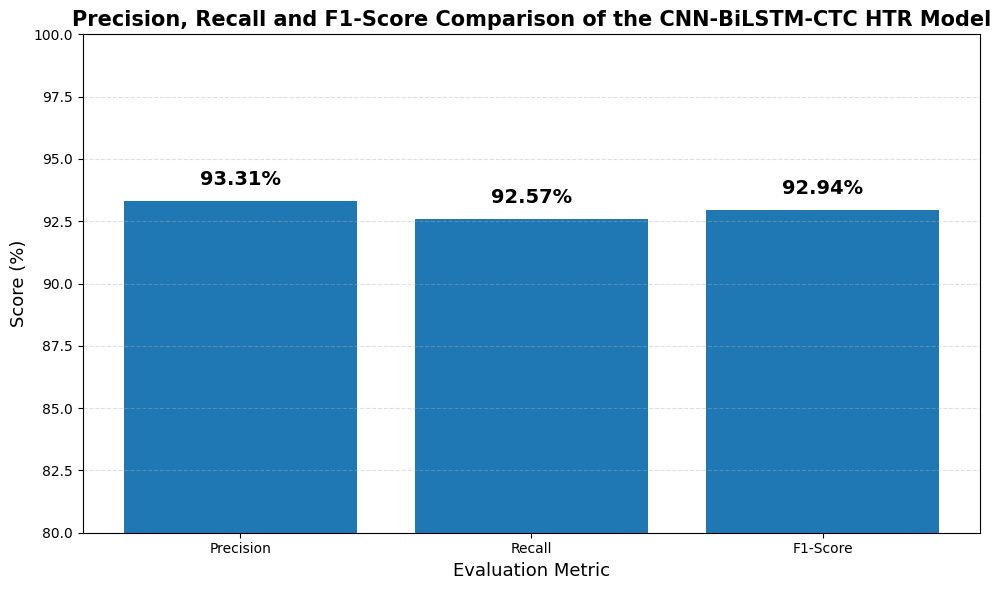

✓ Precision–Recall–F1 chart saved successfully to:
/content/drive/MyDrive/HTR_Model/precision_recall_f1_chart.png


In [56]:
import matplotlib.pyplot as plt

# ==========================================
# CHARACTER-LEVEL EVALUATION METRICS
# ==========================================

metrics = ["Precision", "Recall", "F1-Score"]

scores = [
    93.31,
    92.57,
    92.94
]

# ==========================================
# CREATE FIGURE
# ==========================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metrics,
    scores
)

# ==========================================
# ADD VALUE LABELS
# ==========================================

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

# ==========================================
# GRAPH LABELS
# ==========================================

plt.xlabel(
    "Evaluation Metric",
    fontsize=13
)

plt.ylabel(
    "Score (%)",
    fontsize=13
)

plt.title(
    "Precision, Recall and F1-Score Comparison of the CNN-BiLSTM-CTC HTR Model",
    fontsize=15,
    fontweight="bold"
)

# Focus the graph on the high-score range
plt.ylim(80, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# ==========================================
# SAVE FOR RESEARCH PAPER
# ==========================================

plt.tight_layout()

save_path = "/content/drive/MyDrive/HTR_Model/precision_recall_f1_chart.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Precision–Recall–F1 chart saved successfully to:\n{save_path}")

In [60]:
from collections import Counter

# ============================================================
# CHARACTER-LEVEL PRECISION, RECALL AND F1-SCORE
# ============================================================

total_tp = 0
total_fp = 0
total_fn = 0

for true_text, pred_text in zip(all_true_texts, all_pred_texts):

    # Count characters in ground truth and prediction
    true_counter = Counter(true_text)
    pred_counter = Counter(pred_text)

    # True Positives:
    # Characters correctly predicted, considering frequency
    tp = sum(
        min(true_counter[char], pred_counter[char])
        for char in true_counter
    )

    # False Positives:
    # Extra/wrong predicted characters
    fp = len(pred_text) - tp

    # False Negatives:
    # Missing ground-truth characters
    fn = len(true_text) - tp

    total_tp += tp
    total_fp += fp
    total_fn += fn


# Calculate metrics
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0

recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("CHARACTER-LEVEL PRECISION, RECALL AND F1-SCORE")
print("=" * 60)

print(f"True Positives  : {total_tp}")
print(f"False Positives : {total_fp}")
print(f"False Negatives : {total_fn}")

print("-" * 60)

print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1_score * 100:.2f}%")

print("=" * 60)

CHARACTER-LEVEL PRECISION, RECALL AND F1-SCORE
True Positives  : 15165
False Positives : 1087
False Negatives : 1217
------------------------------------------------------------
Precision : 93.31%
Recall    : 92.57%
F1-Score  : 92.94%


In [48]:
import pandas as pd

# Select representative examples from your validation predictions
sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

results_df = pd.DataFrame({
    "Sample No.": [i + 1 for i in range(len(sample_indices))],
    "Ground Truth": [
        all_ground_truths[i] for i in sample_indices
    ],
    "Predicted Text": [
        all_predictions[i] for i in sample_indices
    ]
})

# Add correctness column
results_df["Status"] = [
    "Correct" if true == pred else "Incorrect"
    for true, pred in zip(
        results_df["Ground Truth"],
        results_df["Predicted Text"]
    )
]

# Display table
print("GROUND TRUTH VS PREDICTED TEXT")
display(results_df)

# Save CSV for research paper
save_path = "/content/drive/MyDrive/HTR_Model/sample_predictions.csv"
results_df.to_csv(save_path, index=False)

print(f"\n✓ Sample predictions saved to:\n{save_path}")

GROUND TRUTH VS PREDICTED TEXT


,Sample No.,Ground Truth,Predicted Text,Status
0,1,Fang-,Fang-,Correct
1,2,",",",",Correct
2,3,-,-,Correct
3,4,course,Cawege,Incorrect
4,5,in,in,Correct
5,6,are,are,Correct
6,7,parties,pastiers,Incorrect
7,8,dealing,dealing,Correct
8,9,troops,troops,Correct
9,10,"""","""",Correct



✓ Sample predictions saved to:
/content/drive/MyDrive/HTR_Model/sample_predictions.csv


In [44]:
import pandas as pd

# Find correct and incorrect samples
correct_indices = [
    i for i, (true, pred) in enumerate(
        zip(all_ground_truths, all_predictions)
    )
    if true == pred
]

incorrect_indices = [
    i for i, (true, pred) in enumerate(
        zip(all_ground_truths, all_predictions)
    )
    if true != pred
]

# Select 5 correct and 5 incorrect examples
selected_indices = correct_indices[:5] + incorrect_indices[:5]

# Create research paper results table
paper_results_df = pd.DataFrame({
    "Sample No.": range(1, len(selected_indices) + 1),
    "Ground Truth": [
        all_ground_truths[i]
        for i in selected_indices
    ],
    "Predicted Text": [
        all_predictions[i]
        for i in selected_indices
    ]
})

# Add result status
paper_results_df["Result"] = [
    "Correct" if true == pred else "Incorrect"
    for true, pred in zip(
        paper_results_df["Ground Truth"],
        paper_results_df["Predicted Text"]
    )
]

print("QUALITATIVE EVALUATION OF HTR MODEL")
display(paper_results_df)

# Save CSV
save_path = (
    "/content/drive/MyDrive/HTR_Model/"
    "qualitative_prediction_results.csv"
)

paper_results_df.to_csv(save_path, index=False)

print(f"\n✓ Research paper table saved to:\n{save_path}")

QUALITATIVE EVALUATION OF HTR MODEL


,Sample No.,Ground Truth,Predicted Text,Result
0,1,Fang-,Fang-,Correct
1,2,",",",",Correct
2,3,-,-,Correct
3,4,in,in,Correct
4,5,are,are,Correct
5,6,course,Cawege,Incorrect
6,7,parties,pastiers,Incorrect
7,8,why,whky,Incorrect
8,9,seven-,semur,Incorrect
9,10,Referring,Reflrrinn,Incorrect



✓ Research paper table saved to:
/content/drive/MyDrive/HTR_Model/qualitative_prediction_results.csv


WORD PERFORMANCE BY LENGTH


,Word Length,Total Samples,Correct Predictions,Exact Match Accuracy (%)
0,1–3,1835,1703,92.806540
1,4–6,1244,861,69.212219
2,7–9,559,306,54.740608
3,10+,193,79,40.932642


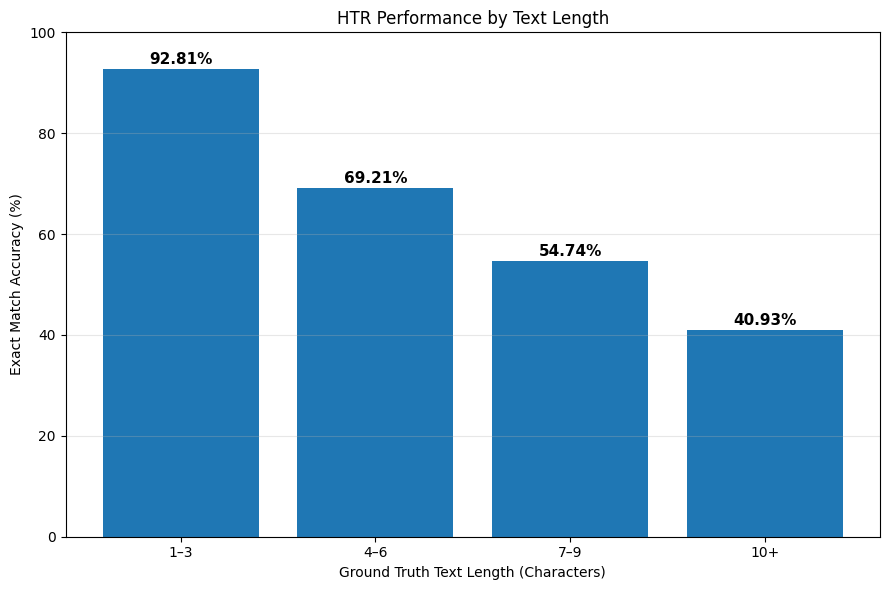

✓ Table saved to: /content/drive/MyDrive/HTR_Model/word_performance_by_length.csv
✓ Graph saved to: /content/drive/MyDrive/HTR_Model/word_performance_by_length.png


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Define word-length groups
bins = {
    "1–3": (1, 3),
    "4–6": (4, 6),
    "7–9": (7, 9),
    "10+": (10, float("inf"))
}

results = []

for group, (min_len, max_len) in bins.items():

    total = 0
    correct = 0

    for true, pred in zip(all_ground_truths, all_predictions):

        # Use character length of the ground-truth text
        text_length = len(true)

        if min_len <= text_length <= max_len:
            total += 1

            if true == pred:
                correct += 1

    accuracy = (correct / total * 100) if total > 0 else 0

    results.append({
        "Word Length": group,
        "Total Samples": total,
        "Correct Predictions": correct,
        "Exact Match Accuracy (%)": accuracy
    })

length_results_df = pd.DataFrame(results)

print("WORD PERFORMANCE BY LENGTH")
display(length_results_df)

# Save table
save_path = "/content/drive/MyDrive/HTR_Model/word_performance_by_length.csv"
length_results_df.to_csv(save_path, index=False)

# Create graph
plt.figure(figsize=(9, 6))

bars = plt.bar(
    length_results_df["Word Length"],
    length_results_df["Exact Match Accuracy (%)"]
)

# Add percentage labels
for bar, value in zip(
    bars,
    length_results_df["Exact Match Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("Ground Truth Text Length (Characters)")
plt.ylabel("Exact Match Accuracy (%)")
plt.title("HTR Performance by Text Length")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

graph_path = "/content/drive/MyDrive/HTR_Model/word_performance_by_length.png"

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Table saved to: {save_path}")
print(f"✓ Graph saved to: {graph_path}")

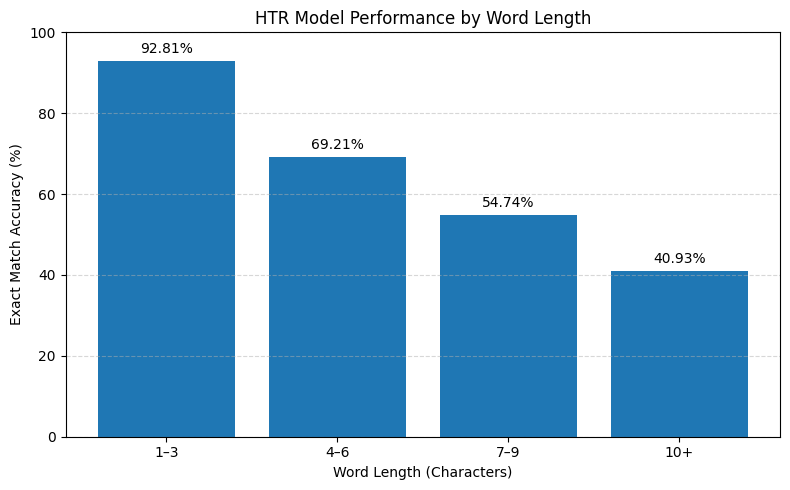

In [46]:
import matplotlib.pyplot as plt

word_lengths = ["1–3", "4–6", "7–9", "10+"]
accuracy = [92.81, 69.21, 54.74, 40.93]

plt.figure(figsize=(8, 5))

plt.bar(word_lengths, accuracy)

plt.xlabel("Word Length (Characters)")
plt.ylabel("Exact Match Accuracy (%)")
plt.title("HTR Model Performance by Word Length")

plt.ylim(0, 100)

for i, value in enumerate(accuracy):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CREATE WORD LENGTH PERFORMANCE DATA
# ============================================================

length_results = []

# Find the maximum word length
max_length = max(len(str(text)) for text in all_ground_truths)

for length in range(1, max_length + 1):

    total = 0
    correct = 0

    for true_text, pred_text in zip(all_ground_truths, all_predictions):

        true_text = str(true_text)
        pred_text = str(pred_text)

        # Check samples having this exact word length
        if len(true_text) == length:
            total += 1

            if true_text == pred_text:
                correct += 1

    # Calculate accuracy
    if total > 0:
        accuracy = (correct / total) * 100
    else:
        accuracy = 0

    length_results.append({
        "Word Length": length,
        "Total Samples": total,
        "Correct Predictions": correct,
        "Word Accuracy (%)": accuracy
    })


# Convert to DataFrame
length_df = pd.DataFrame(length_results)

print("WORD LENGTH PERFORMANCE")
display(length_df)

WORD LENGTH PERFORMANCE


,Word Length,Total Samples,Correct Predictions,Word Accuracy (%)
0,1,475,455,95.789474
1,2,617,581,94.165316
2,3,743,667,89.771198
3,4,534,405,75.842697
4,5,401,266,66.334165
5,6,309,190,61.488673
6,7,267,155,58.052434
7,8,168,89,52.976190
8,9,124,62,50.000000
9,10,102,51,50.000000


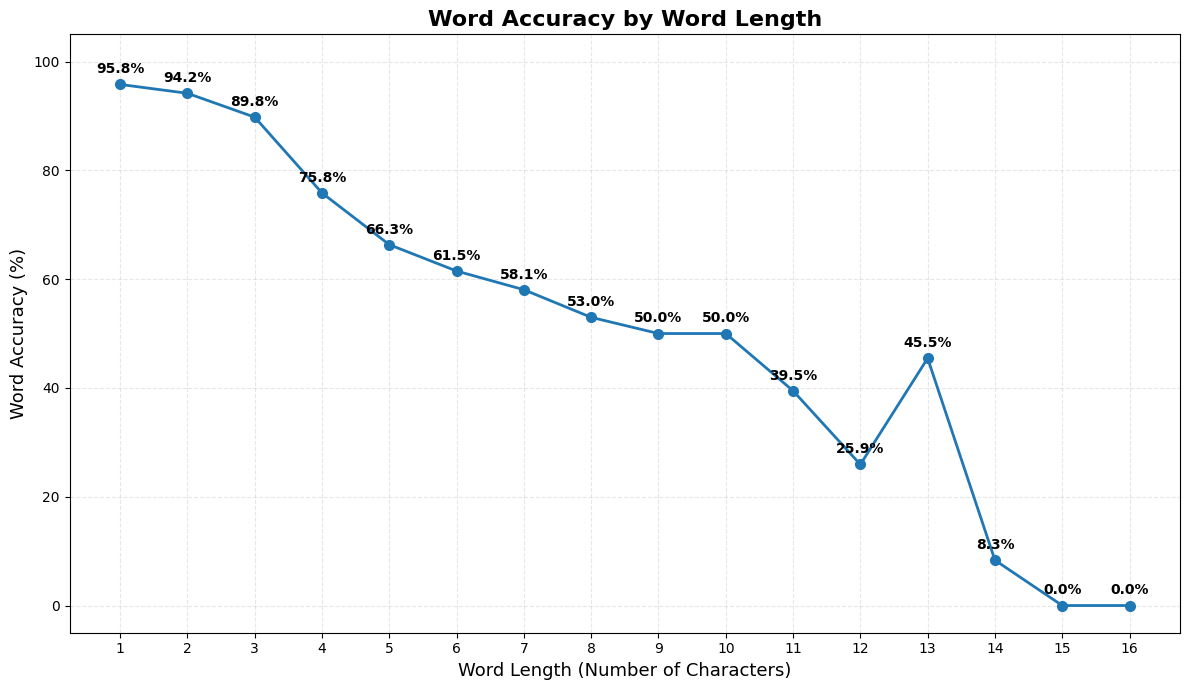

✓ Graph saved successfully!


In [51]:
# ============================================================
# WORD ACCURACY BY EXACT WORD LENGTH
# ============================================================

plt.figure(figsize=(12, 7))

plt.plot(
    length_df["Word Length"],
    length_df["Word Accuracy (%)"],
    marker="o",
    linewidth=2,
    markersize=7
)

# Add percentage labels above each point
for x, y in zip(
    length_df["Word Length"],
    length_df["Word Accuracy (%)"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel(
    "Word Length (Number of Characters)",
    fontsize=13
)

plt.ylabel(
    "Word Accuracy (%)",
    fontsize=13
)

plt.title(
    "Word Accuracy by Word Length",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(length_df["Word Length"])

plt.ylim(-5, 105)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "/content/drive/MyDrive/HTR_Model/word_accuracy_by_exact_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Graph saved successfully!")

In [62]:
import os
import cv2

def is_valid_image(image_path):
    if not os.path.exists(image_path):
        return False

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return False

    return True


print("Checking all samples...")

valid_samples_checked = []
bad_samples = []

for sample in tqdm(samples):

    if is_valid_image(sample["image_path"]):
        valid_samples_checked.append(sample)
    else:
        bad_samples.append(sample)


print("\nValid samples:", len(valid_samples_checked))
print("Bad samples:", len(bad_samples))

print("\nFirst 10 bad samples:")
for sample in bad_samples[:10]:
    print(sample)

Checking all samples...


  0%|          | 0/38304 [00:00<?, ?it/s]


Valid samples: 38304
Bad samples: 0

First 10 bad samples:


In [ ]:
samples = valid_samples_checked

print("Final usable samples:", len(samples))

Final usable samples: 38304


In [ ]:
from sklearn.model_selection import train_test_split

train_samples, val_samples = train_test_split(
    samples,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print("Total samples     :", len(samples))
print("Training samples  :", len(train_samples))
print("Validation samples:", len(val_samples))

Total samples     : 38304
Training samples  : 34473
Validation samples: 3831


In [ ]:
train_dataset = IAMWordDataset(train_samples)
val_dataset = IAMWordDataset(val_samples)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 34473
Validation dataset size: 3831


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 539
Validation batches: 60


In [ ]:
for _ in tqdm(train_loader, desc="Checking training data"):
    pass

print("All training batches loaded successfully!")

Checking training data:   0%|          | 0/539 [00:00<?, ?it/s]

All training batches loaded successfully!


In [ ]:
for _ in tqdm(val_loader, desc="Checking validation data"):
    pass

print("All validation batches loaded successfully!")

Checking validation data:   0%|          | 0/60 [00:00<?, ?it/s]

All validation batches loaded successfully!


In [59]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir("."))

Current directory:
/content

Files in current directory:
['.config', 'data', 'drive', 'sample_data']


In [ ]:
!pip install jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.3 MB/s eta 0:00:00


In [ ]:
from jiwer import wer
from tqdm.auto import tqdm

model.eval()

all_predictions = []
all_actuals = []

with torch.no_grad():

    for batch in tqdm(val_loader, desc="Evaluating validation set"):

        images = batch["images"].to(device)

        # Actual text labels
        actual_texts = batch["texts"]

        # Model predictions
        outputs = model(images)

        # CTC decode
        predicted_texts = ctc_greedy_decode(
            outputs,
            idx_to_char
        )

        all_predictions.extend(predicted_texts)
        all_actuals.extend(actual_texts)


print("Total validation samples:", len(all_actuals))

Evaluating validation set:   0%|          | 0/60 [00:00<?, ?it/s]

Total validation samples: 3831
